In [6]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append("../src")
from synth_defects import make_defect


In [17]:
df = pd.read_csv("../manifest.csv")
clean = df[(df.split == "synth_source")].sample(4, random_state=1)
print(clean)
# resolve paths relative to the notebook directory
project_root = Path("..").resolve()
clean["filepath"] = clean["filepath"].apply(lambda p: str((project_root / p.replace("\\", "/")).resolve()))


                               filepath  label         split
134  data\raw\bottle\train\good\051.png      0  synth_source
242  data\raw\bottle\train\good\159.png      0  synth_source
108  data\raw\bottle\train\good\025.png      0  synth_source
282  data\raw\bottle\train\good\199.png      0  synth_source


In [18]:
from synth_defects import get_mask

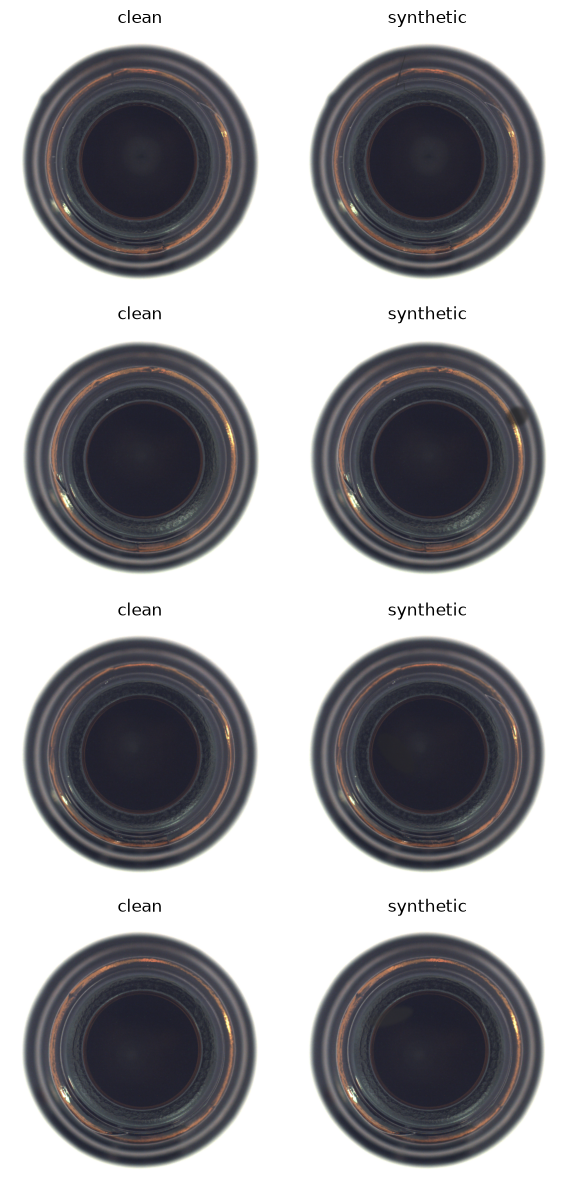

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(6, 12))
for ax_row, (_, r) in zip(axes, clean.iterrows()):
    img_path = r.filepath
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = get_mask(img)
    defect_img = make_defect(img, mask)
    defect_rgb = cv2.cvtColor(defect_img, cv2.COLOR_BGR2RGB)

    ax_row[0].imshow(img_rgb)
    ax_row[0].set_title("clean")
    ax_row[0].axis("off")

    ax_row[1].imshow(defect_rgb)
    ax_row[1].set_title("synthetic")
    ax_row[1].axis("off")

plt.tight_layout()
plt.show()
